# Astro III: Exercise 9

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits
from scipy.interpolate import interp1d


plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15)
plt.rcParams.update({'font.size': 18})

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement scipy.integrade (from versions: none)
ERROR: No matching distribution found for scipy.integrade


## Problem 4: 49 Ceti debris disk

**a)** Read in and plot the total SED of the 49 Ceti system (SED_49$_Cet.dat). What part of the electromagnetic spectrum (e.g. X-ray, optical, UV) do the observations belong to? What features can you identify?

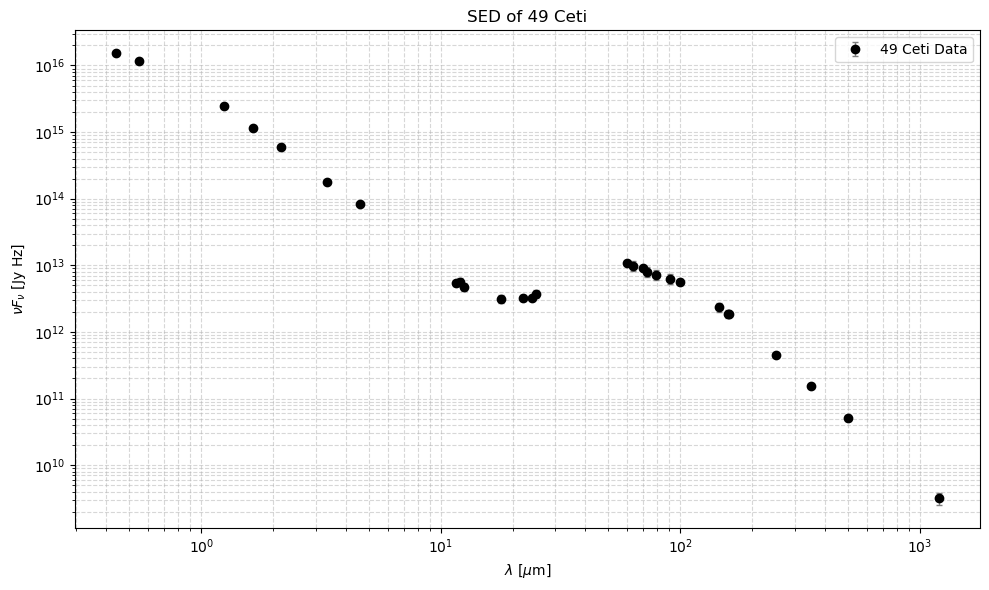

In [7]:
# Read in the spectrum. 
# Wavelength is in mum and Flux in Jy

data_SED = np.loadtxt("SED_49_Cet.dat")

# Extract columns: Wavelength (um), Flux (Jy), and Flux Error (Jy)
SED_lam = data_SED[:, 0]
SED_F   = data_SED[:, 1]
SED_Fe  = data_SED[:, 2]

# Convert F_nu (Jy) to SED representation: nu * F_nu [Jy * Hz]
c = 3.0e14  # speed of light in um/s
nu_F_nu = (c / SED_lam) * SED_F
nu_F_nu_e = (c / SED_lam) * SED_Fe

# Plot the SED
plt.figure(figsize=(10, 6))
plt.errorbar(SED_lam, nu_F_nu, yerr=nu_F_nu_e, fmt='o', color='black', 
             ecolor='gray', elinewidth=1, capsize=2, label='49 Ceti Data')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\lambda$ [$\mu$m]')
plt.ylabel(r'$\nu F_{\nu}$ [Jy Hz]')
plt.title('SED of 49 Ceti')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**b)** Previous studies have shown that 49 Ceti is an A1V star with $T = 9000$K. The corresponding ATLAS9 stellar model (Castelli $\&$ Kurucz 2004) is provided with this exercise sheet. Read in the model, normalise it to fit the stellar part of the SED, and use it to estimate the stellar radius.

In [10]:
# read in the ATLAS9 model


data_model = np.loadtxt("ATLAS9_9000_40.dat")
model_lam = data_model[:,0]
model_F = data_model[:,1]



In [11]:
# mask only stellar component
mask_star = SED_lam < 2
lam_star = SED_lam[mask_star]
F_star = SED_F[mask_star]
Fe_star = SED_Fe[mask_star]

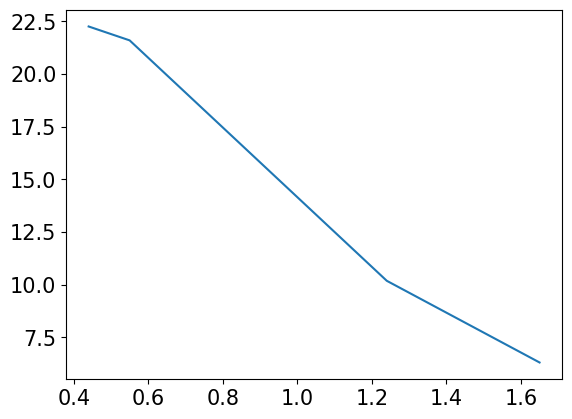

In [19]:
# Interpolate the ATLAS9 model flux to evaluate it at the exact observed wavelengths (lam_star)
f_interp = interp1d(model_lam, model_F, kind='linear')
model_F_interp = f_interp(lam_star)

# Find the scaling factor to normalize the model to the stellar photometry
# Using a weighted least-squares scale factor: scale = sum(F_obs * F_mod / err^2) / sum(F_mod^2 / err^2)
scale = np.sum((F_star * model_F_interp) / Fe_star**2) / np.sum((model_F_interp / Fe_star)**2)

plt.plot(lam_star, F_star)

# Normalized model flux across the entire wavelength range
model_F_normalized = model_F * scale

In [17]:
# --- Estimate Stellar Radius R_* ---
# The observed flux F_obs and stellar surface flux F_surface (model_F) are related by:
# F_obs = (R_* / d)^2 * F_surface  =>  scale factor = (R_* / d)^2
d_pc = 59.0  # distance in parsecs
pc_to_m = 3.0857e16
R_sun_m = 6.957e8

d_m = d_pc * pc_to_m
R_star_m = np.sqrt(scale) * d_m
R_star_Rsun = R_star_m / R_sun_m

print(f"Scaling factor: {scale:.3e}")
print(f"Estimated Stellar Radius: {R_star_Rsun:.2f} R_sun")

Scaling factor: 1.391e+01
Estimated Stellar Radius: 9758680452.21 R_sun


In [ ]:
# Convert F[Jy] to F_lambda and integrate to get F
# use c_mum_s = (2.99e+8)*1.e+6
c_mum_s = 
F_star = 

# Compute L
d_m = 
L_star = 

# Compute stellar radius
def compute_stellar_radius(luminosity, temperature):

# Convert to solar mass


**c)** Fit the disk part of the SED using a modified black body model:

In [ ]:
# mask only disk component
mask_disk = 

lam_disk = 
F_disk = 
Fe_disk = 

In [ ]:
# Define the black body function
def mod_black_body(wavelength, temperature, normalization, lam_0, beta):


In [ ]:
# Initial guesses for the parameters
T_guess =         # Wien's law for lam = 50 mum
A_guess = 20
lam_0_guess = 155 * 1e-6
beta_guess = 0.5

# Initial guess tuple for temperature, normalization, lam_0, tao_0, beta
initial_guess_mod = (T_guess, A_guess, lam_0_guess, beta_guess)

# Fit the black body curve to the data
popt, pcov = curve_fit(mod_black_body, lam_disk, F_disk, p0=initial_guess_mod)

# Print the fitted parameters


In [ ]:
# plot


**d)** Sum the models you've obtained for the stellar and disk parts of the SED to get the overall model, and plot it against the data. Does the model fit the whole SED well? If not, what does this tell you? What is missing?

In [ ]:
# create total model

model_lam_tot = 

model_tot_star = 

model_tot_BB = 

model_tot = 

# plot total model


**e)** Based on the models that you obtained above, compute the fractional infrared luminosity $L_{dust} / L_{\star}$. This is defined as the ratio of the black body model integrated over all frequencies to the similarly integrated stellar model.

In [ ]:
# Integrate to get Flux


# Convert to Luminosity and get ratio

# Get ratio

**f)** Compute the total CII mass for the cases $T_{gas} = 20, 100, 1000$K

In [ ]:
# read in and plot data

data_CII = 
CII_lam = 
CII_F = 
CII_Fe = 

In [ ]:
# Define the Gaussian function
def gaussian(x, amplitude, mean, stddev, const):

# Initial guesses for the parameters


# Initial guess tuple for amplitude, mean, and standard deviation

# Fit the Gaussian curve to the data

# Extract the fitted parameters


# Plot the data and the fitted Gaussian


# Print the fitted parameters



In [ ]:
# Compute CII Flux in W m^-2


In [ ]:
# compute MCII

Ax_20K = 4.06e-08
Ax_100K = 9.93e-07
Ax_1000K = 1.45e-06

def get_MCII(lam0, Fint, m, d, Ax):
    